In [1]:
from pathlib import Path
from collections import Counter
import re,math,unicodedata

In [5]:
PATH_WORK = str(Path.cwd().parent)
ALL_DATA_CLEANED = PATH_WORK + "\data\cleaned\ka_cleaned.txt"

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
E:\TMP\ipykernel_5768\2002427448.py:2: SyntaxWarning: invalid escape sequence '\d'
  ALL_DATA_CLEANED = PATH_WORK + "\data\cleaned\ka_cleaned.txt"


In [6]:
WORD_RE = re.compile(r"[ა-ჰ\u10A0-\u10FF\u2D00-\u2D2F\u1C90-\u1CBF]+(?:[-'][ა-ჰ\u10A0-\u10FF\u2D00-\u2D2F\u1C90-\u1CBF]+)?|[A-Za-z0-9]+")


In [7]:
def tokenize(line: str):
    line = unicodedata.normalize("NFKC", line)
    return [m.group(0).lower() for m in WORD_RE.finditer(line)]

# 读取并统计
tokens = []
sent_lens = []
with open(ALL_DATA_CLEANED, encoding="utf-8") as f:
    for line in f:
        toks = tokenize(line.strip())
        if not toks: 
            continue
        tokens.extend(toks)
        sent_lens.append(len(toks))

N = len(tokens)                 # token 总数
V = len(set(tokens))            # 词型数（types）
freq = Counter(tokens)          # 词频表

# 指标
TTR = V / N                     # Type-Token Ratio
hapax = sum(1 for w,c in freq.items() if c == 1)
dislegomena = sum(1 for w,c in freq.items() if c == 2)
avg_sent_len = sum(sent_lens) / len(sent_lens)

print(f"Tokens: {N:,}")
print(f"Vocab size (types): {V:,}")
print(f"TTR: {TTR:.4f}")
print(f"Hapax count: {hapax:,}  ({hapax/V:.1%} of vocab)")
print(f"Dislegomena: {dislegomena:,}")
print(f"Avg sentence length (tokens): {avg_sent_len:.2f}")

# Top-50 词
print("\nTop-50:")
for i, (w, c) in enumerate(freq.most_common(50), 1):
    print(f"{i:>2}. {w}\t{c}")

Tokens: 31,587,637
Vocab size (types): 1,901,440
TTR: 0.0602
Hapax count: 516,826  (27.2% of vocab)
Dislegomena: 1,002,869
Avg sentence length (tokens): 15.25

Top-50:
 1. eos	2071589
 2. და	962186
 3. რომ	377900
 4. არ	299020
 5. ეს	175107
 6. ამ	166874
 7. უნდა	118073
 8. ის	112350
 9. არის	109828
10. თუ	108672
11. კი	104438
12. იყო	101364
13. საქართველოს	100341
14. რომელიც	82200
15. როგორც	82072
16. მაგრამ	72963
17. მისი	72919
18. რაც	72225
19. მე	71518
20. წლის	71003
21. რა	67068
22. შემდეგ	66331
23. განაცხადა	55431
24. მათ	55134
25. თუმცა	54781
26. ვერ	54573
27. ჩვენ	54108
28. იმ	52214
29. ძალიან	52158
30. დღეს	50794
31. შესახებ	50643
32. news	49770
33. ასევე	49085
34. არა	48386
35. ერთი	48343
36. ყველა	47388
37. აქვს	46752
38. მას	45567
39. მხოლოდ	44965
40. იქნება	44234
41. სხვა	44128
42. ან	43000
43. თქმით	42617
44. მიერ	41985
45. უფრო	41942
46. დიდი	41866
47. უკვე	41590
48. შორის	40253
49. კიდევ	38083
50. ჩვენი	37730


In [8]:
def coverage_at_k(counter, ks=(1000, 2000, 4000, 8000, 16000, 32000)):
    tot = sum(counter.values())
    arr = counter.most_common()
    out = {}
    for k in ks:
        k = min(k, len(arr))
        covered = sum(c for _, c in arr[:k])
        out[k] = covered / tot
    return out

cov = coverage_at_k(freq)
print("\nCoverage:")
for k, r in cov.items():
    print(f"Top-{k:<6} -> {r:>6.2%}")



Coverage:
Top-1000   -> 45.36%
Top-2000   -> 52.94%
Top-4000   -> 60.84%
Top-8000   -> 68.51%
Top-16000  -> 75.35%
Top-32000  -> 81.06%


tOP-16K covers only 75%, therefore 32k vocab_size is necessary.
And I did try both of them with bpe, it turns out:
16000:
avg subwords / sentence: 23.09986556558479
p50 / p90 / p99 length: 21.0 39 57
32000:
avg subwords / sentence: 20.57393892836566
p50 / p90 / p99 length: 19.0 35 51

In [9]:

def ngrams(seq, n):
    return zip(*[seq[i:] for i in range(n)])

# bigram / trigram（基于整语料，亦可逐句统计）
bigrams = Counter(ngrams(tokens, 2))
trigrams = Counter(ngrams(tokens, 3))

print("\nTop-20 bigrams:")
for (a,b), c in bigrams.most_common(20):
    print(f"{a} {b}\t{c}")

print("\nTop-20 trigrams:")
for (a,b,c), n in trigrams.most_common(20):
    print(f"{a} {b} {c}\t{n}")

# 句长桶
import numpy as np
bins = [0,5,10,15,20,30,50,100]
hist, edges = np.histogram(sent_lens, bins=bins)
print("\nSentence length buckets (tokens):")
for i in range(len(hist)):
    print(f"{edges[i]:>3.0f}–{edges[i+1]:<3.0f}: {hist[i]:>8}")

# 可选：停用词过滤影响（自行准备 stopwords_ka.txt）
STOP = set()
if Path("stopwords_ka.txt").exists():
    STOP = set(w.strip() for w in open("stopwords_ka.txt", encoding="utf-8") if w.strip())

if STOP:
    freq_nostop = Counter(w for w in tokens if w not in STOP)
    cov_ns = coverage_at_k(freq_nostop)
    print("\nCoverage w/o stopwords:")
    for k, r in cov_ns.items():
        print(f"Top-{k:<6} -> {r:>6.2%}")



Top-20 bigrams:
news eos	49225
არ არის	28598
იყო eos	21205
ეს არის	16861
თუ არა	15030
რომ ეს	14425
ამის შესახებ	14384
მათ შორის	13610
არ უნდა	13368
მისი თქმით	12662
რაც შეეხება	12348
განაცხადა რომ	10550
უნდა იყოს	9941
იქნება eos	9753
და სხვა	9646
აქვს eos	9638
და მისი	9613
არის eos	9481
და ეს	9408
თქმა უნდა	8795

Top-20 trigrams:
რა თქმა უნდა	8556
არ არის eos	6373
მიუხედავად იმისა რომ	4271
მას შემდეგ რაც	3317
geotimes სიახლეებიძალოვანი სტრუქტურებიარატრადიციული	3092
სიახლეებიძალოვანი სტრუქტურებიარატრადიციული მედიცინა	3092
24 hours სახელმწიფო	3032
hours სახელმწიფო პროგრამები	3032
და ა შ	2936
ცოტა ხნის წინ	2487
შინაგან საქმეთა სამინისტროს	2410
რუსთავი 2 ის	2283
ეს არ არის	2164
არ უნდა იყოს	1904
არ აქვს eos	1875
რამდენიმე დღის წინ	1872
და აღნიშნა რომ	1850
იმის გამო რომ	1834
უნდა იყოს eos	1713
იმ შემთხვევაში თუ	1688

Sentence length buckets (tokens):
  0–5  :     1324
  5–10 :   449190
 10–15 :   661087
 15–20 :   463249
 20–30 :   426812
 30–50 :    64004
 50–100:     5921


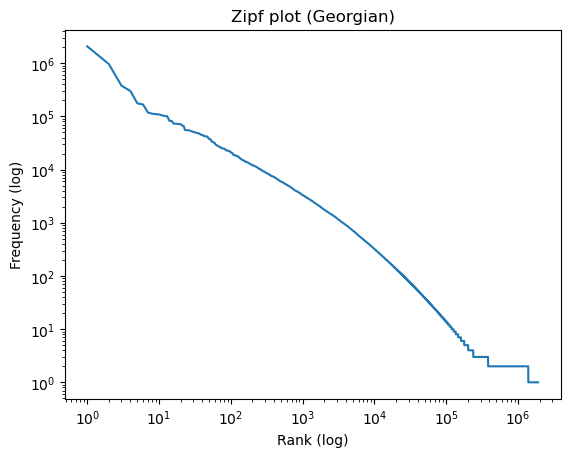

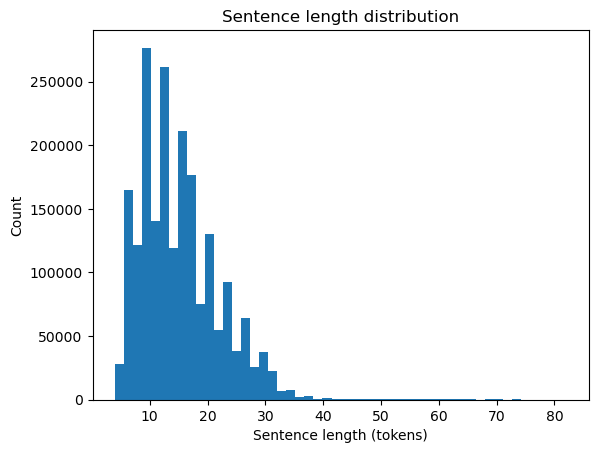

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Zipf：词频按排名
counts = np.array([c for _, c in freq.most_common()])
ranks = np.arange(1, len(counts)+1)

plt.figure()
plt.loglog(ranks, counts)
plt.xlabel("Rank (log)")
plt.ylabel("Frequency (log)")
plt.title("Zipf plot (Georgian)")
plt.show()

# 句长分布
plt.figure()
plt.hist(sent_lens, bins=50)
plt.xlabel("Sentence length (tokens)")
plt.ylabel("Count")
plt.title("Sentence length distribution")
plt.show()


In [14]:
# Train SentencePiece tokenizers at multiple vocab sizes
import sentencepiece as spm
from pathlib import Path

clean_train = Path(PATH_WORK+"/data/splits/train.txt")   # 已清洗后的 train
tok_dir = Path("tokenizer"); tok_dir.mkdir(parents=True, exist_ok=True)

sizes = [16000, 24000, 32000]
for vs in sizes:
    model_prefix = tok_dir / f"spm_unigram_{vs}"
    spm.SentencePieceTrainer.Train(
        input=clean_train,
        model_prefix=str(model_prefix),
        vocab_size=vs,
        model_type="unigram",
        character_coverage=0.9995,
        input_sentence_size=2000000,  
        shuffle_input_sentence=True,
        num_threads=4,
        train_extremely_large_corpus=True,
        unk_id=0, bos_id=1, eos_id=2, pad_id=-1  # 无 pad
    )
print("Done.")


Done.


In [17]:
# Evaluate compression & length stats for each tokenizer
import numpy as np, sentencepiece as spm

val_path = Path(PATH_WORK+"/data/splits/val.txt")
with open(val_path, "r", encoding="utf-8") as f:
    val_lines = [x.strip() for x in f if x.strip()]

def eval_tok(model_path, lines, max_lines=50000):
    sp = spm.SentencePieceProcessor(model_file=model_path)
    n = min(max_lines, len(lines))
    L = lines[:n]
    subword_lens, char_lens = [], []
    for s in L:
        ids = sp.encode(s, out_type=int)
        subword_lens.append(len(ids))
        char_lens.append(len(s))
    subword_lens = np.array(subword_lens)
    char_lens = np.array(char_lens)
    tpc = subword_lens.sum() / char_lens.sum()  # tokens per char
    return {
        "lines": n,
        "avg_subwords_per_sent": float(subword_lens.mean()),
        "p50": float(np.percentile(subword_lens, 50)),
        "p90": float(np.percentile(subword_lens, 90)),
        "p99": float(np.percentile(subword_lens, 99)),
        "tokens_per_char": float(tpc)
    }

for vs in [16000, 24000, 32000]:
    stats = eval_tok(f"tokenizer/spm_unigram_{vs}.model", val_lines)
    print(f"[{vs}] ->", stats)


[16000] -> {'lines': 20715, 'avg_subwords_per_sent': 28.801351677528363, 'p50': 26.0, 'p90': 45.0, 'p99': 67.0, 'tokens_per_char': 0.24069545179111596}
[24000] -> {'lines': 20715, 'avg_subwords_per_sent': 27.234081583393674, 'p50': 25.0, 'p90': 43.0, 'p99': 63.0, 'tokens_per_char': 0.22759763653542495}
[32000] -> {'lines': 20715, 'avg_subwords_per_sent': 26.263190924450882, 'p50': 24.0, 'p90': 41.0, 'p99': 62.0, 'tokens_per_char': 0.21948381714213788}


To avoid cost too much on this, we implement 24k.
